## 🧪 Segmentation Testing Notebook Overview

This notebook provides a complete, plug-and-play interface for evaluating our trained **YOLOv8 segmentation models** on a set of 17 testing images. It is designed so that anyone can load the best-performing models, run inference, and visually compare results without needing to understand the underlying training pipeline.

### What this notebook does

- **Loads the trained models** saved in the `models/` folder  
  - `best_yolov8m_resnet.pt` — YOLOv8m with SSL-pretrained ResNet50 backbone  
  - `best_yolov8s.pt` — YOLOv8s with SSL-pretrained ResNet50 backbone
- **Loads all testing images** from the `testing_images/` directory and prepares them for inference.

- **Runs inference on all images** with each model and automatically saves annotated outputs (segmentation masks + bounding boxes) into:
`for_testing/segmentation_testing_outputs/<model_name>/`


- Provides **utility functions** to:
- Visualize predictions from a single model
- Compare multiple models **side-by-side** on the same image
- Select a random sample or manually specify an image to test

### Why this notebook is useful

- Creates a standardized evaluation pipeline for all segmentation models.
- Allows quick visual QC of lesion/cervix/SCJ segmentation performance.
- Makes it easy to compare baseline vs hybrid models on identical data.

### Folder structure expected

```
for_testing/
│
├── testing_functions.ipynb      # ← this notebook
│
├── testing_images/              # ~17 images to evaluate
│     ├── img1.jpg
│     ├── img2.png
│     └── ...
│
└── models/
      ├── best_yolov8m_resnet.pt
      └── best_yolov8s.pt

```

Use this notebook as a unified, repeatable way to test any new segmentation models we produce.


In [ ]:
import os
from pathlib import Path
import random

import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image

# -------------------
# Paths (edit if needed)
# -------------------
ROOT_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path(".")
TEST_ROOT = ROOT_DIR  # this notebook lives in for_testing/

MODEL_DIR = TEST_ROOT / "models"
IMAGE_DIR = TEST_ROOT / "testing_images"
OUTPUT_DIR = TEST_ROOT / "segmentation_testing_outputs"

# Model paths
MODEL_PATHS = {
    "yolov8m_resnet": MODEL_DIR / "best_yolov8m_resnet.pt",
    "yolov8s":        MODEL_DIR / "best_yolov8s.pt",
}

# Create output directory if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Check images
all_images = sorted(
    [p for p in IMAGE_DIR.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
)
print(f"Found {len(all_images)} testing images in '{IMAGE_DIR}'.")
if len(all_images) == 0:
    print("⚠️ No images found! Please add ~30 images to the 'testing_images' folder.")


Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\niran\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cpu
Found 17 testing images in 'testing_images'.


In [2]:
# Load YOLO segmentation models
models = {}

for name, path in MODEL_PATHS.items():
    if not path.exists():
        print(f"⚠️ Model weights not found: {path}")
        continue

    print(f"Loading model '{name}' from {path} ...")
    models[name] = YOLO(str(path))
    # Force model onto chosen device
    models[name].to(device)

print(f"Loaded models: {list(models.keys())}")


Loading model 'yolov8m_resnet' from models\best_yolov8m_resnet.pt ...
Loading model 'yolov8s' from models\best_yolov8s.pt ...
Loaded models: ['yolov8m_resnet', 'yolov8s']


In [3]:
def run_inference_on_folder(model, model_name, image_dir, output_root,
                            imgsz=640, conf=0.25):
    """
    Run YOLO segmentation on all images in `image_dir`.
    Annotated images are saved under:
        output_root / model_name / image_basename
    """
    out_dir = output_root / model_name
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n=== Running inference for '{model_name}' ===")
    print(f"Saving annotated images to: {out_dir}")

    results = model.predict(
        source=str(image_dir),
        imgsz=imgsz,
        conf=conf,
        save=True,          # save annotated images
        save_txt=False,     # don't save txt labels by default
        project=str(output_root),
        name=model_name,
        exist_ok=True,
        device=device,
        verbose=True,
    )

    print(f"Done. Processed {len(results)} images.")
    return results


In [4]:
all_results = {}

for model_name, model in models.items():
    results = run_inference_on_folder(
        model=model,
        model_name=model_name,
        image_dir=IMAGE_DIR,
        output_root=OUTPUT_DIR,
        imgsz=640,
        conf=0.25,
    )
    all_results[model_name] = results

print("Inference complete for all available models.")



=== Running inference for 'yolov8m_resnet' ===
Saving annotated images to: testing_outputs\yolov8m_resnet

image 1/17 c:\Users\niran\OneDrive\Documents\GitHub\via-cervical-screening\for_testing\testing_images\via_img_001_jpg.rf.4a64b03107076d0999856ffc450ac8cb_crop.jpg: 416x640 1 Cervix, 439.7ms
image 2/17 c:\Users\niran\OneDrive\Documents\GitHub\via-cervical-screening\for_testing\testing_images\via_img_009_jpg.rf.2864b3ab7eb8cb9f275f12832805f0ab_crop.jpg: 416x640 1 Cervix, 1 Lesion, 328.1ms
image 3/17 c:\Users\niran\OneDrive\Documents\GitHub\via-cervical-screening\for_testing\testing_images\via_img_013_jpg.rf.7e98ced52fe9e9973cda9eaae53e00d4_crop.jpg: 416x640 1 Cervix, 1 Nabothian Cyst, 335.6ms
image 4/17 c:\Users\niran\OneDrive\Documents\GitHub\via-cervical-screening\for_testing\testing_images\via_img_018_jpg.rf.3849de0d365d9486070a0d725295aabe_crop.jpg: 416x640 1 Cervix, 1 IUCD String, 286.6ms
image 5/17 c:\Users\niran\OneDrive\Documents\GitHub\via-cervical-screening\for_testing\te

In [5]:
def show_single_model_prediction(model, image_path, figsize=(6, 6), conf=0.25):
    """
    Run prediction on a single image and display it.
    """
    results = model.predict(
        source=str(image_path),
        conf=conf,
        imgsz=640,
        device=device,
        verbose=False,
    )

    res = results[0]
    plotted = res.plot()  # returns a numpy array (BGR)
    img_rgb = plotted[:, :, ::-1]  # convert BGR -> RGB for matplotlib

    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"{image_path.name}")
    plt.show()


In [6]:
def show_single_model_prediction(model, image_path, figsize=(6, 6), conf=0.25):
    """
    Run prediction on a single image and display it.
    """
    results = model.predict(
        source=str(image_path),
        conf=conf,
        imgsz=640,
        device=device,
        verbose=False,
    )

    res = results[0]
    plotted = res.plot()  # returns a numpy array (BGR)
    img_rgb = plotted[:, :, ::-1]  # convert BGR -> RGB for matplotlib

    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"{image_path.name}")
    plt.show()


In [7]:
def compare_models_on_image(image_path, model_dict, figsize=(12, 6), conf=0.25):
    """
    Run all loaded models on a single image and show them side-by-side.
    model_dict: dict like {"yolov8m_resnet": model_obj, "yolov8s": model_obj}
    """
    n_models = len(model_dict)
    if n_models == 0:
        print("No models loaded.")
        return

    plt.figure(figsize=figsize)

    for idx, (name, model) in enumerate(model_dict.items(), start=1):
        results = model.predict(
            source=str(image_path),
            conf=conf,
            imgsz=640,
            device=device,
            verbose=False,
        )
        res = results[0]
        plotted = res.plot()
        img_rgb = plotted[:, :, ::-1]  # BGR -> RGB

        plt.subplot(1, n_models, idx)
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(name)

    plt.suptitle(f"Comparison on: {image_path.name}")
    plt.tight_layout()
    plt.show()


Random test image: via_img_018_jpg.rf.3849de0d365d9486070a0d725295aabe_crop.jpg


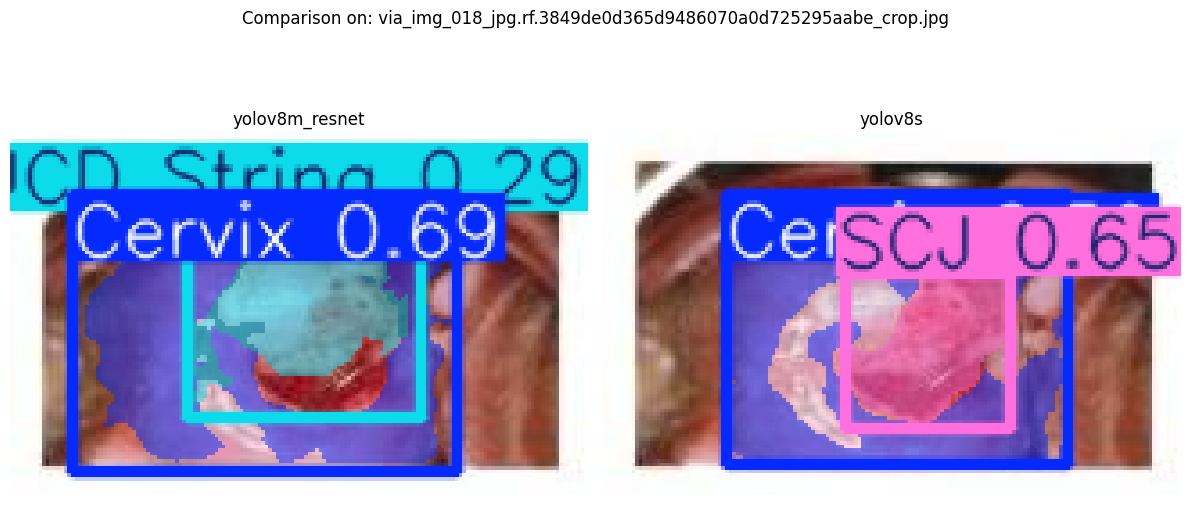

In [8]:
if len(all_images) == 0 or len(models) == 0:
    print("⚠️ Cannot compare models: missing images or models.")
else:
    sample_img = random.choice(all_images)
    print(f"Random test image: {sample_img.name}")
    compare_models_on_image(sample_img, models, conf=0.25)


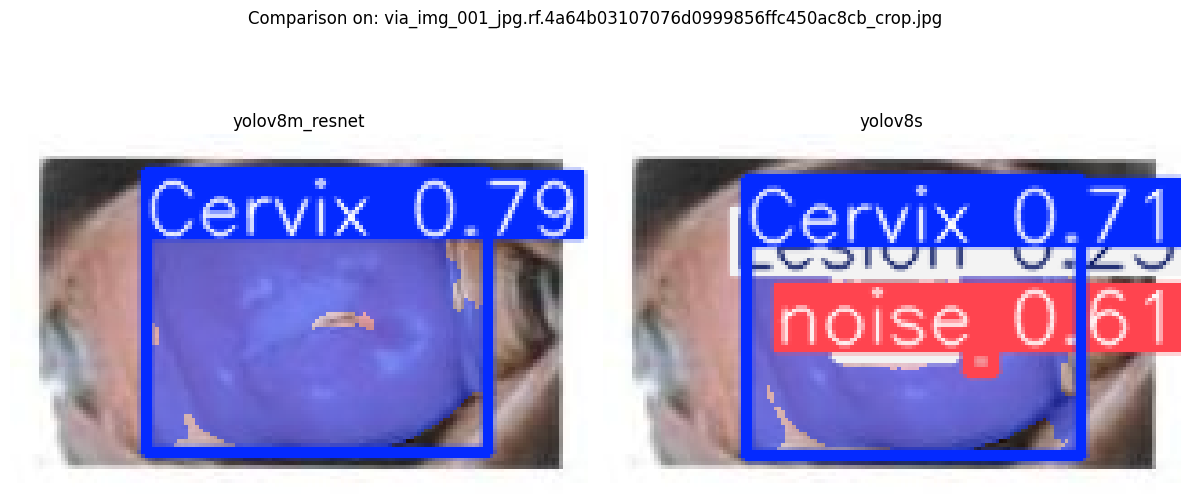

In [9]:
# Change this to any filename that exists in testing_images
FILENAME = "via_img_001_jpg.rf.4a64b03107076d0999856ffc450ac8cb_crop.jpg"  # <-- EDIT THIS

chosen_path = IMAGE_DIR / FILENAME
if chosen_path.exists():
    compare_models_on_image(chosen_path, models, conf=0.25)
else:
    print(f"File not found in testing_images: {chosen_path}")
    print("Available examples:")
    for p in all_images[:10]:
        print("  -", p.name)
